Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
\n--- Loading Base Data and Creating Engineered Features ---
Successfully loaded 'clean_numeric_model.csv'.
\n✅ Engineered data successfully saved as 'clean_numeric_engineered_v2.csv'.
\nTotal Features (including target and index) Ready: 35
Target Class Balance: Counter({0: 25003, 1: 24997})
First 5 columns of the saved data: ['row_id', 'User_ID', 'Age', 'Sleep_Hours', 'Work_Hours']
\n✅ Chunk 1 Complete: Setup and feature engineering finished.


[I 2025-10-11 10:07:21,679] A new study created in memory with name: no-name-9e387d9f-d667-43c5-b0f9-500ed1290165


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-10-11 10:07:26,800] Trial 0 finished with value: 0.49619745687138594 and parameters: {'max_depth': 7, 'learning_rate': 0.1667521176194013, 'subsample': 0.9195981825434215, 'colsample_bytree': 0.8795975452591109, 'gamma': 0.7800932022121826, 'reg_alpha': 8.629132190071849e-05, 'reg_lambda': 2.231010801867923e-05}. Best is trial 0 with value: 0.49619745687138594.
[I 2025-10-11 10:07:31,790] Trial 1 finished with value: 0.42388817557938985 and parameters: {'max_depth': 11, 'learning_rate': 0.045918988705873284, 'subsample': 0.9124217733388136, 'colsample_bytree': 0.7061753482887407, 'gamma': 4.8495492608099715, 'reg_alpha': 0.9877700294007907, 'reg_lambda': 0.00018794668241638458}. Best is trial 0 with value: 0.49619745687138594.
[I 2025-10-11 10:07:39,920] Trial 2 finished with value: 0.49869536903712425 and parameters: {'max_depth': 5, 'learning_rate': 0.009835468046820034, 'subsample': 0.7912726728878613, 'colsample_bytree': 0.8574269294896714, 'gamma': 2.1597250932105787, 'reg

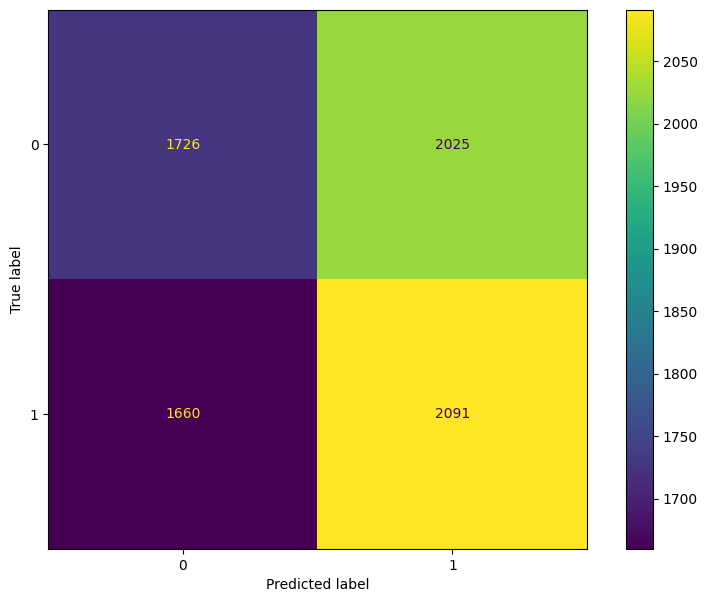

\nAUC Score: 0.5098
Brier Score: 0.2500
--- SHAP Summary Plot ---


/tmp/ipython-input-35308215.py:297: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train, plot_type="bar")
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


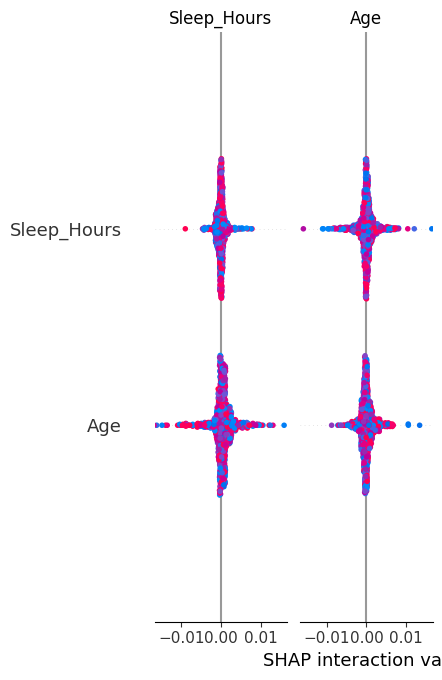

Logistic Regression Baseline F1 Score (weighted): 0.4902


In [11]:
# Chunk 1: Setup, Feature Engineering, and Data Preparation for XGBoost

# Install necessary packages in Colab, including XGBoost
!pip install optuna shap xgboost -q

import logging
from pathlib import Path
from typing import Tuple, Dict, Any, List
from collections import Counter
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_auc_score, brier_score_loss
)
# --- XGBoost Import ---\n",
from xgboost import XGBClassifier
from IPython.display import display
import xgboost

# --- Mount Google Drive ---
from google.colab import drive
try:
    drive.mount('/content/drive')
except:
    print("Drive already mounted or unavailable. Skipping mount.")

# --------- logging ---------
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)
RND = 42
np.random.seed(RND) # Set global seed for reproducibility

# --- Define the path to your data ---
# --- Define the path to your data on Google Drive ---
DRIVE_DATA_PATH = Path("/content/drive/MyDrive/MachineLearning/data/processed_V2")
FINAL_ENGINEERED_FILE = "clean_numeric_engineered_v2.csv" # New file name

# --- Execute the setup and feature engineering ---
print("\\n--- Loading Base Data and Creating Engineered Features ---")
try:
    BASE_FILE_NAME = "clean_numeric_model.csv"
    # User_ID is used as the row_id/index in the splits file, so we read it without setting an index
    base_df = pd.read_csv(DRIVE_DATA_PATH / BASE_FILE_NAME)
    print(f"Successfully loaded '{BASE_FILE_NAME}'.")

    # Store the row_id/index needed for merging splits
    base_df = base_df.reset_index().rename(columns={"index": "row_id"})

    # --- Feature Engineering ---
    base_df['Work_Sleep_Ratio'] = base_df['Work_Hours'] / (base_df['Sleep_Hours'] + 0.01)
    base_df['Stress_x_Smoking'] = base_df['Stress_Level_ord'] * base_df['Smoking_Habit_ord']
    base_df['Stress_x_Alcohol'] = base_df['Stress_Level_ord'] * base_df['Alcohol_Consumption_ord']
    base_df['High_Risk_Pattern_Flag'] = ( (base_df['Stress_Level_ord'] >= 2) & (base_df['Sleep_Hours'] < 6) & (base_df['Physical_Activity_Hours'] < 2)).astype(int)
    base_df['Sleep_Deviation'] = abs(base_df['Sleep_Hours'] - 7.5)
    base_df['Digital_Overload_Score'] = base_df['Work_Hours'] + base_df['Social_Media_Usage']
    base_df['Age_Squared'] = base_df['Age']**2
    base_df['Age_x_SM_Usage'] = base_df['Age'] * base_df['Social_Media_Usage']
    base_df['Age_x_Work_Hours'] = base_df['Age'] * base_df['Work_Hours']
    base_df['Health_Habit_Deficit'] = (
        (base_df['Sleep_Deviation'] / 3.0) +
        (3 - base_df['Diet_Quality_ord']) +
        (10 - base_df['Physical_Activity_Hours']) / 10
    )

    # --- CRITICAL SAVE STEP ---
    base_df.to_csv(DRIVE_DATA_PATH / FINAL_ENGINEERED_FILE, index=False)
    print(f"\\n✅ Engineered data successfully saved as '{FINAL_ENGINEERED_FILE}'.")
    # ---------------------------

    # Define target
    # CHANGE: Switched to the multi-class target column
    TARGET = 'Mental_Health_Condition_lbl'
    # Check current status
    y = base_df[TARGET]

    print(f"\\nTotal Features (including target and index) Ready: {len(base_df.columns)}")
    print(f"Target Class Balance: {Counter(y)}")
    print(f"First 5 columns of the saved data: {base_df.columns[:5].tolist()}")


except FileNotFoundError:
    print(f"ERROR: Could not find the base '{BASE_FILE_NAME}' file.")
except KeyError as e:
    print(f"ERROR: Column {e} not found. Please check your feature/target names.")


print("\\n✅ Chunk 1 Complete: Setup and feature engineering finished.")

# Chunk 2: Define All Core Functions for XGBoost (Multi-Class Version)

# --- Standard Imports ---
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
import shap
import matplotlib.pyplot as plt
import logging
from pathlib import Path
from typing import Tuple, Dict, Any, List

# --- Scikit-learn Imports ---
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, brier_score_loss
from xgboost import XGBClassifier
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

# --- Configuration ---
RND = 42
logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO)

# ==============================================================================
# 1. DATA LOADING FUNCTION
# ==============================================================================
def load_and_split_data(base_dir: Path) -> Tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
    """
    REVISED: Switched to the multi-class target, ensures all identifiers including 'row_id'
    are dropped from the feature sets (X) at the source.
    """
    data_path = base_dir / "clean_numeric_engineered_v2.csv"
    splits_path = base_dir / "splits_70_15_15_k5.csv"

    if not data_path.exists() or not splits_path.exists():
        raise FileNotFoundError(f"Data files not found in {base_dir}.")

    df = pd.read_csv(data_path)
    if "row_id" not in df.columns:
        df = df.reset_index().rename(columns={"index": "row_id"})

    splits = pd.read_csv(splits_path)
    df = df.merge(splits, on="row_id", how="left")

    train_df, val_df, test_df = df[df["split"] == "train"].copy(), df[df["split"] == "val"].copy(), df[df["split"] == "test"].copy()

    # CHANGE: Switched to the multi-class target column
    TARGET_COL = "Mental_Health_Condition_lbl"

    # REVISION: Added "row_id" to the drop list to avoid filtering it in every function.
    # CHANGE: Removed multi-class target from drop list, added binary target to drop list
    drop_list = ["User_ID", "Severity_ord", "Has_MH_condition_bin", "split", "cv_fold", "row_id", TARGET_COL]
    drop_cols = [c for c in drop_list if c in train_df.columns]

    X_train, y_train = train_df.drop(columns=drop_cols), train_df[TARGET_COL].astype(int)
    X_val, y_val = val_df.drop(columns=drop_cols), val_df[TARGET_COL].astype(int)
    X_test, y_test = test_df.drop(columns=drop_cols), test_df[TARGET_COL].astype(int)

    logger.info(f"Loaded splits: train={len(y_train)}, val={len(y_val)}, test={len(y_test)}")
    return X_train, y_train, X_val, y_val, X_test, y_test

# ==============================================================================
# 2. HYPERPARAMETER TUNING FUNCTION
# ==============================================================================
def tune_xgb_optuna(
    X_train: pd.DataFrame, y_train: pd.Series,
    n_trials: int = 30, cv_folds: int = 5,
) -> Tuple[Any, Dict[str, Any]]:
    """
    REVISED: Adapted for multi-class classification.
    """
    X, y = X_train.copy().reset_index(drop=True), y_train.copy().reset_index(drop=True)

    # CHANGE: Get the number of classes from the training data
    num_class = y_train.nunique()

    def obj(trial: "optuna.trial.Trial") -> float:
        params = {
            "max_depth": trial.suggest_int("max_depth", 4, 12),
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
            "subsample": trial.suggest_float("subsample", 0.7, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
            "gamma": trial.suggest_float("gamma", 0, 5),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-5, 10, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-5, 10, log=True),
            # CHANGE: Objective and eval_metric for multi-class, added num_class
            "objective": "multi:softmax",
            "eval_metric": "mlogloss",
            "num_class": num_class,
            "n_estimators": 5000,
            "random_state": RND,
            "tree_method": "hist",
            "n_jobs": -1
        }

        skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RND)
        f1s, best_iters_fold = [], []

        for tr_idx, va_idx in skf.split(X, y):
            X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
            y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

            clf = XGBClassifier(early_stopping_rounds=100, **params)
            clf.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

            y_pred = clf.predict(X_va)

            # CHANGE: Use weighted F1 score for multi-class
            f1 = f1_score(y_va, y_pred, average="weighted")
            f1s.append(f1)

            best_iters_fold.append(clf.best_iteration)
            if trial.should_prune():
                raise optuna.TrialPruned()

        trial.set_user_attr("avg_best_iter", np.mean(best_iters_fold))
        return float(np.mean(f1s))

    study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=RND), pruner=MedianPruner())
    study.optimize(obj, n_trials=n_trials, show_progress_bar=True)

    best_params = study.best_params
    avg_iter = study.best_trial.user_attrs.get("avg_best_iter", 500)
    best_params["n_estimators"] = int(np.clip(int(1.1 * avg_iter), 100, 5000))

    return study, best_params

# ==============================================================================
# 3. FINAL MODEL TRAINING FUNCTION
# ==============================================================================
def train_final_xgb(
    X_train: pd.DataFrame, y_train: pd.Series, X_val: pd.DataFrame, y_val: pd.Series,
    params: Dict[str, Any],
) -> XGBClassifier:
    """
    REVISED: Trains the final multi-class XGBoost model.
    """
    # CHANGE: Get the number of classes from the training data
    num_class = y_train.nunique()

    model = XGBClassifier(
        # CHANGE: Objective and eval_metric for multi-class, added num_class
        objective='multi:softmax',
        eval_metric='mlogloss',
        num_class=num_class,
        random_state=RND,
        n_jobs=-1,
        early_stopping_rounds=50,
        **params
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    logger.info("Trained final XGBoost. Best iter: %s", model.best_iteration)
    return model

# ==============================================================================
# 4. EVALUATION FUNCTIONS
# ==============================================================================
# CHANGE: Removed find_optimal_threshold as it's not applicable for multi-class with softmax
def evaluate_model(model: XGBClassifier, X_test: pd.DataFrame, y_test: pd.Series):
    """
    REVISED: Evaluates the model, now including AUC and Brier Score for the binary case.
    """
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    print("--- Classification Report ---")
    print(classification_report(y_test, y_pred))

    print("\\n--- Confusion Matrix ---")
    fig, ax = plt.subplots(figsize=(10, 7))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax)
    plt.show()

    # REVISED: AUC and Brier Score for the binary classification case.
    # We use the probabilities of the positive class (class 1).
    auc_score = roc_auc_score(y_test, y_prob[:, 1])
    brier_score = brier_score_loss(y_test, y_prob[:, 1])

    print(f"\\nAUC Score: {auc_score:.4f}")
    print(f"Brier Score: {brier_score:.4f}")


# ==============================================================================
# 5. SHAP ANALYSIS FUNCTION
# ==============================================================================
def explain_model_with_shap(model: XGBClassifier, X_train: pd.DataFrame):
    """
    Visualizes feature importance using SHAP.
    NOTE: For multi-class, SHAP can provide explanations per class.
    Here we show a summary plot of the mean absolute SHAP values.
    """
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_train)

    print("--- SHAP Summary Plot ---")
    shap.summary_plot(shap_values, X_train, plot_type="bar")
    plt.show()

# Chunk 3: Main Execution Block for Multi-Class XGBoost
try:
    # 1. Load Data
    X_train, y_train, X_val, y_val, X_test, y_test = load_and_split_data(DRIVE_DATA_PATH)

    # 2. Hyperparameter Tuning
    study, best_params = tune_xgb_optuna(X_train, y_train, n_trials=30)
    print(f"\\n🏆 Best F1 (weighted) from Optuna: {study.best_value:.4f}")
    print("📋 Best Hyperparameters:")
    for k, v in best_params.items():
        print(f"  - {k}: {v}")

    # 3. Train Final Model
    final_model = train_final_xgb(X_train, y_train, X_val, y_val, best_params)

    # 4. Evaluate on Test Set
    evaluate_model(final_model, X_test, y_test)

    # 5. Explain with SHAP
    explain_model_with_shap(final_model, X_train.sample(1000, random_state=RND)) # Using a sample for speed

except FileNotFoundError as e:
    logger.error(f"A data file was not found: {e}")
except Exception as e:
    logger.error(f"An unexpected error occurred: {e}", exc_info=True)

# Chunk 4: Baseline Logistic Regression (for comparison)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data ONLY and transform all sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Don't forget to scale the test data too

# Train a simple baseline ON THE SCALED DATA
log_reg = LogisticRegression(random_state=RND, max_iter=1000)
log_reg.fit(X_train_scaled, y_train) # <-- Use X_train_scaled here

# Evaluate ON THE SCALED DATA
# CHANGE: Use predict instead of predict_proba, and weighted f1_score
y_pred_log_reg = log_reg.predict(X_test_scaled)
f1 = f1_score(y_test, y_pred_log_reg, average='weighted')
print(f"Logistic Regression Baseline F1 Score (weighted): {f1:.4f}")